In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

results_df = pd.read_csv("simulation_results.csv")

results_df.head()

,timestamp,station_id,actual_utilization,predicted_utilization,applied_tariff,baseline_revenue,agent_revenue
0,2022-07-18 23:15:00,681,0.500000,0.510857,15.0,450.0,450.0
1,2022-07-18 23:15:00,775,1.000000,0.976527,22.5,450.0,675.0
2,2022-07-18 23:15:00,937,1.000000,0.976527,22.5,450.0,675.0
3,2022-07-18 23:15:00,1119,1.000000,1.000000,22.5,450.0,675.0
4,2022-07-18 23:15:00,890,0.333333,0.388234,15.0,450.0,450.0


In [2]:
monitor_df = pd.DataFrame({

    "Metric":[

        "RMSE",
        "MAE",
        "R² Score",

        "Baseline Revenue",
        "Agent Revenue",

        "Revenue Gain %",
        "Off-Peak Uplift Sessions"

    ],

    "Value":[

        0.0712,
        0.0272,
        0.9543,

        900000,
        1179225,

        31.03,
        265

    ]
})

monitor_df

,Metric,Value
0,RMSE,7.120000e-02
1,MAE,2.720000e-02
2,R² Score,9.543000e-01
3,Baseline Revenue,9.000000e+05
4,Agent Revenue,1.179225e+06
5,Revenue Gain %,3.103000e+01
6,Off-Peak Uplift Sessions,2.650000e+02


In [3]:
monitor_df.to_csv(
    "monitoring_results.csv",
    index=False
)

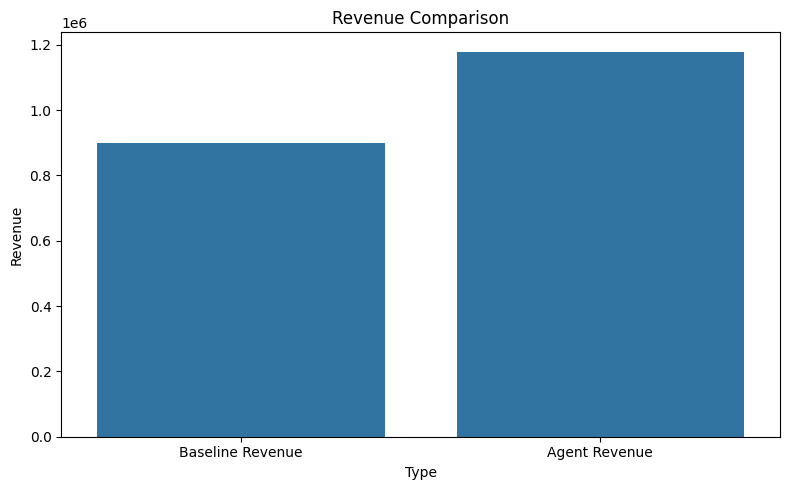

In [4]:
revenue_df = pd.DataFrame({

    "Type":[
        "Baseline Revenue",
        "Agent Revenue"
    ],

    "Revenue":[
        900000,
        1179225
    ]
})

plt.figure(figsize=(8,5))

sns.barplot(
    data=revenue_df,
    x="Type",
    y="Revenue"
)

plt.title(
    "Revenue Comparison"
)

plt.tight_layout()

plt.savefig(
    "revenue_comparison.png",
    dpi=300
)

plt.show()

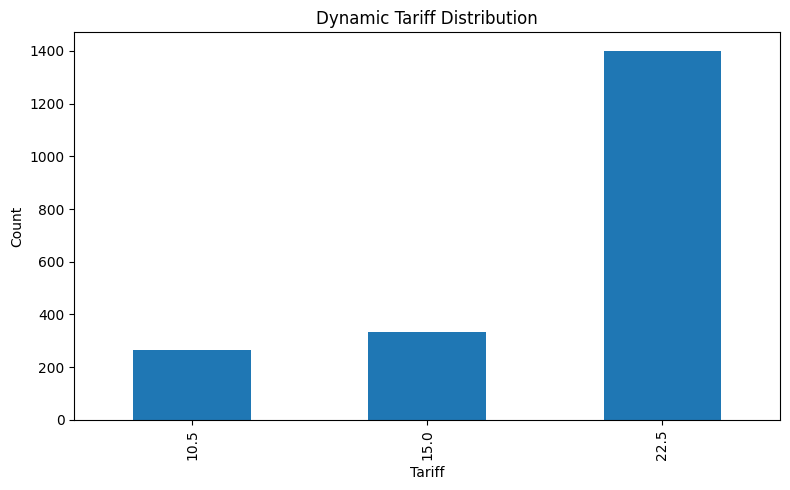

In [5]:
plt.figure(figsize=(8,5))

results_df["applied_tariff"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title(
    "Dynamic Tariff Distribution"
)

plt.xlabel("Tariff")

plt.ylabel("Count")

plt.tight_layout()

plt.savefig(
    "tariff_distribution.png",
    dpi=300
)

plt.show()

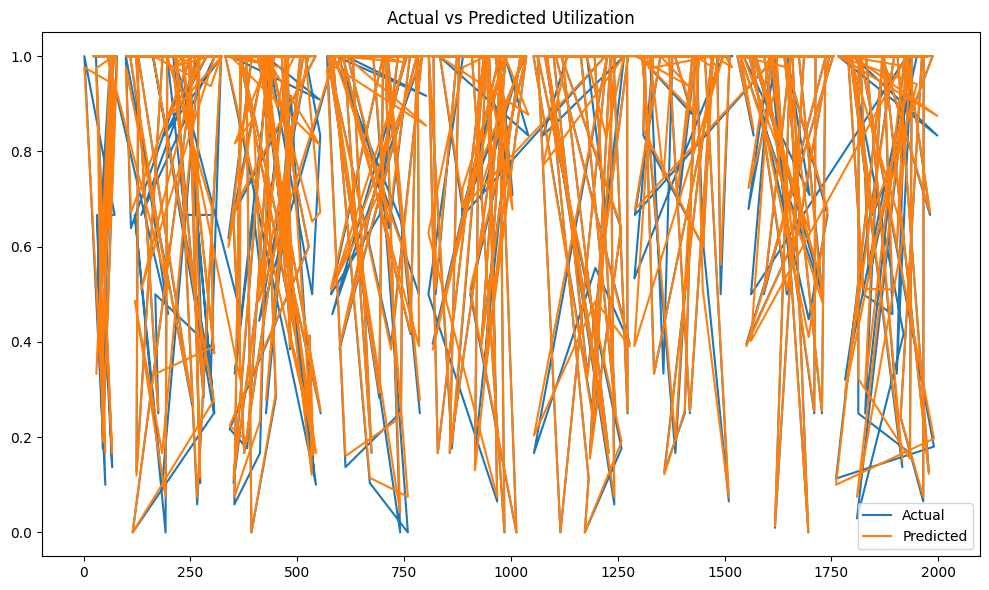

In [6]:
plt.figure(figsize=(10,6))

sample = results_df.sample(
    500,
    random_state=42
).sort_values("timestamp")

plt.plot(
    sample["actual_utilization"],
    label="Actual"
)

plt.plot(
    sample["predicted_utilization"],
    label="Predicted"
)

plt.title(
    "Actual vs Predicted Utilization"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "actual_vs_predicted.png",
    dpi=300
)

plt.show()

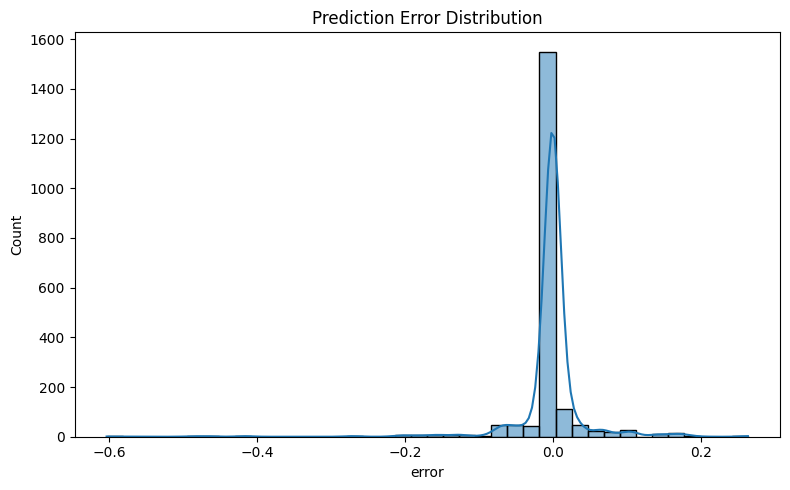

In [7]:
results_df["error"] = (
    results_df["actual_utilization"]
    -
    results_df["predicted_utilization"]
)

plt.figure(figsize=(8,5))

sns.histplot(
    results_df["error"],
    bins=40,
    kde=True
)

plt.title(
    "Prediction Error Distribution"
)

plt.tight_layout()

plt.savefig(
    "error_distribution.png",
    dpi=300
)

plt.show()

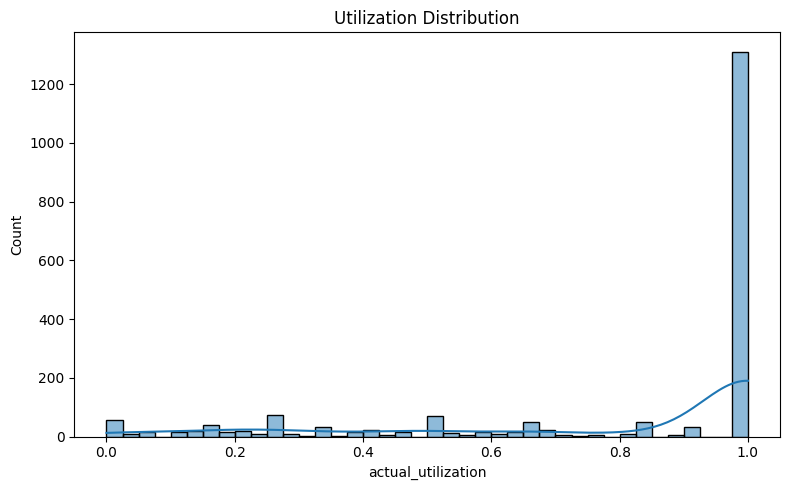

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(
    results_df["actual_utilization"],
    bins=40,
    kde=True
)

plt.title(
    "Utilization Distribution"
)

plt.tight_layout()

plt.savefig(
    "utilization_distribution.png",
    dpi=300
)

plt.show()

In [9]:
business_df = pd.DataFrame({

    "Business KPI":[

        "Revenue Gain %",
        "Off-Peak Uplift Sessions",
        "Baseline Revenue",
        "Agent Revenue"

    ],

    "Value":[

        "31.03%",
        265,
        "₹900,000",
        "₹1,179,225"

    ]
})

business_df

,Business KPI,Value
0,Revenue Gain %,31.03%
1,Off-Peak Uplift Sessions,265
2,Baseline Revenue,"₹900,000"
3,Agent Revenue,"₹1,179,225"


In [10]:
business_df.to_csv(
    "business_metrics.csv",
    index=False
)